Лучше использовать в Google Colab и подключаться к среде выполенения TPU, тк обьем RAM, слишком большой. Предварительно файл conn.log.zip нужно загрузить сюда.

---

## Установка необходимых библиотек



In [1]:
# Установка необходимых библиотек
!pip install numpy pandas scikit-learn tensorflow matplotlib seaborn



---
## Распаковка файла логов



In [2]:
# Распаковка файла логов
!unzip /content/conn.log.zip


Archive:  /content/conn.log.zip
  inflating: conn.log                
  inflating: __MACOSX/._conn.log     



---
## Импорт библиотек



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight



---
## Определение названий колонок



In [4]:
# Определение названий колонок (20 столбцов)
columns_full = [
    "timestamp", "session_id", "src_ip", "src_port", "dst_ip", "dst_port",
    "protocol", "app_protocol", "duration", "bytes_sent", "bytes_received",
    "packets_sent", "packets_received", "flags", "unknown1", "unknown2",
    "unknown3", "unknown4", "unknown5", "additional_info"
]



---
## Чтение лог-файла с обработкой ошибок



In [5]:
# Чтение всего файла с пропуском некорректных строк
try:
    df_full = pd.read_csv(
        'conn.log',
        sep='\t',
        header=None,
        names=columns_full,
        na_values='(empty)',
        on_bad_lines='skip'
    )
    print("Размер DataFrame:", df_full.shape)
    print(df_full.head())
except Exception as e:
    print("Ошибка при чтении файла:", e)


<ipython-input-5-a22520f9b31c>:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(


Размер DataFrame: (22694356, 20)
      timestamp          session_id          src_ip  src_port  \
0  1.331901e+09  CCUIP21wTjqkj8ZqX5  192.168.202.79     50463   
1  1.331901e+09  Csssjd3tX0yOTPDpng  192.168.202.79     46117   
2  1.331901e+09  CHEt7z3AzG4gyCNgci  192.168.202.79     50465   
3  1.331901e+09  CKnDAp2ohlvN6rpiXl  192.168.202.79     50467   
4  1.331901e+09    CGUBcoXKxBE8gTNl  192.168.202.79     46119   

            dst_ip  dst_port protocol app_protocol  duration bytes_sent  \
0  192.168.229.251        80      tcp            -         -          -   
1  192.168.229.254       443      tcp            -         -          -   
2  192.168.229.251        80      tcp         http  0.010000        166   
3  192.168.229.251        80      tcp         http  0.010000        166   
4  192.168.229.254       443      tcp          ssl  0.020000        544   

  bytes_received packets_sent packets_received  flags   unknown1  unknown2  \
0              -           SH                - 


---
## Удаление ненужных столбцов



In [6]:
# Удаление всех столбцов после 'packets_received'
columns_to_keep = [
    "timestamp", "session_id", "src_ip", "src_port", "dst_ip", "dst_port",
    "protocol", "app_protocol", "duration", "bytes_sent", "bytes_received",
    "packets_sent", "packets_received"
]

df = df_full[columns_to_keep]
print("Размер DataFrame после удаления столбцов:", df.shape)
print(df.head())
print("Общее количество элементов в DataFrame:", df.size)


Размер DataFrame после удаления столбцов: (22694356, 13)
      timestamp          session_id          src_ip  src_port  \
0  1.331901e+09  CCUIP21wTjqkj8ZqX5  192.168.202.79     50463   
1  1.331901e+09  Csssjd3tX0yOTPDpng  192.168.202.79     46117   
2  1.331901e+09  CHEt7z3AzG4gyCNgci  192.168.202.79     50465   
3  1.331901e+09  CKnDAp2ohlvN6rpiXl  192.168.202.79     50467   
4  1.331901e+09    CGUBcoXKxBE8gTNl  192.168.202.79     46119   

            dst_ip  dst_port protocol app_protocol  duration bytes_sent  \
0  192.168.229.251        80      tcp            -         -          -   
1  192.168.229.254       443      tcp            -         -          -   
2  192.168.229.251        80      tcp         http  0.010000        166   
3  192.168.229.251        80      tcp         http  0.010000        166   
4  192.168.229.254       443      tcp          ssl  0.020000        544   

  bytes_received packets_sent packets_received  
0              -           SH                -  
1  


---
## Преобразование данных



In [7]:
# Преобразование временной метки в datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Преобразование числовых колонок
numeric_cols = ['duration', 'bytes_sent', 'bytes_received', 'packets_sent', 'packets_received']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.head())
print("Общее количество элементов после преобразования:", df.size)


<ipython-input-7-24f16ae3b14f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
<ipython-input-7-24f16ae3b14f>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors='coerce')


                      timestamp          session_id          src_ip  src_port  \
0 2012-03-16 12:30:00.000000000  CCUIP21wTjqkj8ZqX5  192.168.202.79     50463   
1 2012-03-16 12:30:00.000000000  Csssjd3tX0yOTPDpng  192.168.202.79     46117   
2 2012-03-16 12:30:00.000000000  CHEt7z3AzG4gyCNgci  192.168.202.79     50465   
3 2012-03-16 12:30:00.009999990  CKnDAp2ohlvN6rpiXl  192.168.202.79     50467   
4 2012-03-16 12:30:00.000000000    CGUBcoXKxBE8gTNl  192.168.202.79     46119   

            dst_ip  dst_port protocol app_protocol  duration  bytes_sent  \
0  192.168.229.251        80      tcp            -       NaN         NaN   
1  192.168.229.254       443      tcp            -       NaN         NaN   
2  192.168.229.251        80      tcp         http      0.01       166.0   
3  192.168.229.251        80      tcp         http      0.01       166.0   
4  192.168.229.254       443      tcp          ssl      0.02       544.0   

   bytes_received  packets_sent  packets_received  
0   


---
## Замена пропущенных значений на 0



In [8]:
# Замена пропущенных значений на 0
print("Пропущенные значения до заполнения:")
print(df.isnull().sum())

df = df.fillna(0)

print("Пропущенные значения после заполнения:")
print(df.isnull().sum())
print(df.head())
print("Общее количество элементов после заполнения:", df.size)


Пропущенные значения до заполнения:
timestamp                  0
session_id                 0
src_ip                     0
src_port                   0
dst_ip                     0
dst_port                   0
protocol                   0
app_protocol               0
duration            18791087
bytes_sent          18791087
bytes_received      18791087
packets_sent        22694356
packets_received    22694356
dtype: int64
Пропущенные значения после заполнения:
timestamp           0
session_id          0
src_ip              0
src_port            0
dst_ip              0
dst_port            0
protocol            0
app_protocol        0
duration            0
bytes_sent          0
bytes_received      0
packets_sent        0
packets_received    0
dtype: int64
                      timestamp          session_id          src_ip  src_port  \
0 2012-03-16 12:30:00.000000000  CCUIP21wTjqkj8ZqX5  192.168.202.79     50463   
1 2012-03-16 12:30:00.000000000  Csssjd3tX0yOTPDpng  192.168.202.79     46


---
## Разметка данных



In [9]:
# Инициализация меток
df['label'] = 'Normal'  # Изначально все записи считаем нормальными
print("Общее количество элементов после инициализации меток:", df.size)
print(df['label'].value_counts())


Общее количество элементов после инициализации меток: 317720984
label
Normal    22694356
Name: count, dtype: int64



### Определение функций для разметки



In [10]:
def label_brute_force(df):
    """
    Метка 'Brute-Force' для IP, с которых инициировано более 50 уникальных сессий
    и попыток подключения к более чем 10 портам.
    """
    brute_force_ips = df.groupby('src_ip').filter(
        lambda x: x['session_id'].nunique() > 50 and x['dst_port'].nunique() > 10
    )
    df.loc[brute_force_ips.index, 'label'] = 'Brute-Force'
    return df

def label_ddos(df):
    """
    Метка 'DDoS' для IP, с которых осуществляется более 1000 подключений за сутки.
    """
    df['date'] = df['timestamp'].dt.date
    ddos_ips = df.groupby(['src_ip', 'date']).size().reset_index(name='counts')
    ddos_ips = ddos_ips[ddos_ips['counts'] > 1000]['src_ip'].unique()
    df.loc[df['src_ip'].isin(ddos_ips), 'label'] = 'DDoS'
    df = df.drop('date', axis=1)
    return df

def label_suspicious(df):
    """
    Метка 'Suspicious' для IP с объемом переданных или полученных данных > 1GB
    или использующих нестандартные порты (>1024).
    """
    suspicious_ips = df.groupby('src_ip').filter(
        lambda x: (x['bytes_sent'].sum() + x['bytes_received'].sum()) > 1e9 or x['dst_port'].max() > 1024
    )
    df.loc[suspicious_ips.index, 'label'] = 'Suspicious'
    return df

def label_flooding(df):
    """
    Метка 'Flooding' для IP, инициирующих более 500 подключений к разным портам.
    """
    flooding_ips = df.groupby('src_ip').filter(
        lambda x: x['dst_port'].nunique() > 500
    )
    df.loc[flooding_ips.index, 'label'] = 'Flooding'
    return df

def label_spoofing(df):
    """
    Метка 'Spoofing' для IP, соответствующих внутренним IP-адресам.
    """
    internal_ip_pattern = r'^192\.168\.\d+\.\d+$|^fe80::'
    spoofing_condition = df['src_ip'].str.match(internal_ip_pattern)
    df.loc[spoofing_condition, 'label'] = 'Spoofing'
    return df



### Применение функций разметки



In [11]:
# Применение функций разметки
df = label_brute_force(df)
df = label_ddos(df)
df = label_suspicious(df)
df = label_flooding(df)
df = label_spoofing(df)

# Проверка распределения меток
print("\nРаспределение меток:")
print(df['label'].value_counts())



Распределение меток:
label
Spoofing      22561050
Flooding         61302
Suspicious       56580
DDoS             14142
Normal            1282
Name: count, dtype: int64



---
## Балансировка данных



In [12]:
# Определение целевых размеров для каждого класса
target_sizes = {
    'Spoofing': 52485,
    'Flooding': 61302,
    'Suspicious': 56580,
    'DDoS': 14142,
    'Normal': 1282
}

# Создание отдельных DataFrame для каждого класса
spoofing = df[df['label'] == 'Spoofing']
flooding = df[df['label'] == 'Flooding']
suspicious = df[df['label'] == 'Suspicious']
ddos = df[df['label'] == 'DDoS']
normal = df[df['label'] == 'Normal']

# Подвыборка класса Spoofing
spoofing_sampled = spoofing.sample(n=target_sizes['Spoofing'], random_state=42)

# Объединение сбалансированных классов
balanced_df = pd.concat([spoofing_sampled, flooding, suspicious, ddos, normal])

# Перемешивание данных
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Проверка нового распределения классов
print("\nРаспределение классов после балансировки:")
print(balanced_df['label'].value_counts())



Распределение классов после балансировки:
label
Flooding      61302
Suspicious    56580
Spoofing      52485
DDoS          14142
Normal         1282
Name: count, dtype: int64



---
## Визуализация данных

### Топ-10 IP по количеству подключений



<ipython-input-13-5538a70fc518>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ips.values, y=top_ips.index, palette='viridis')


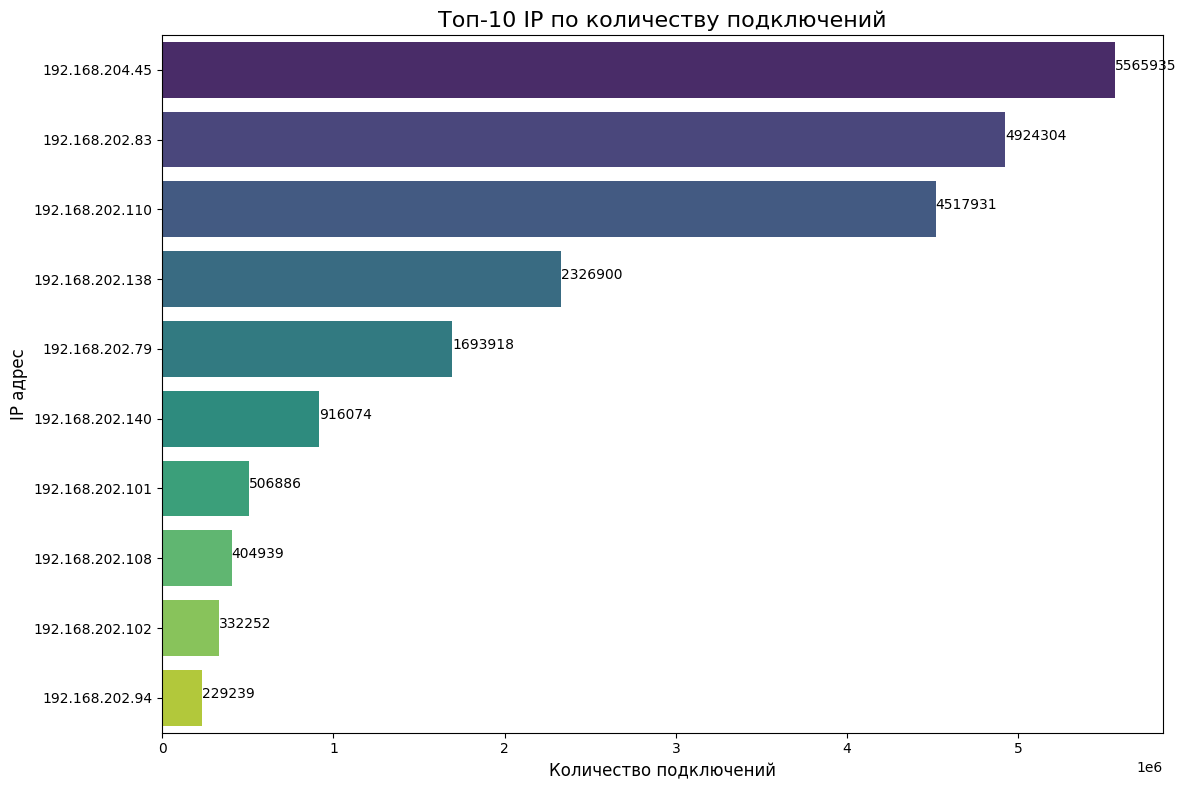

In [13]:
# Топ-10 IP по количеству подключений
top_ips = df['src_ip'].value_counts().head(10)
plt.figure(figsize=(12,8))
sns.barplot(x=top_ips.values, y=top_ips.index, palette='viridis')
plt.xlabel('Количество подключений', fontsize=12)
plt.ylabel('IP адрес', fontsize=12)
plt.title('Топ-10 IP по количеству подключений', fontsize=16)
for index, value in enumerate(top_ips.values):
    plt.text(value, index, str(value))
plt.tight_layout()
plt.show()



### Временной график активности по числу подключений за сутки (по часам)



<ipython-input-14-8768a8dd78d0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_activity.index, y=hourly_activity.values, palette='Blues_d')


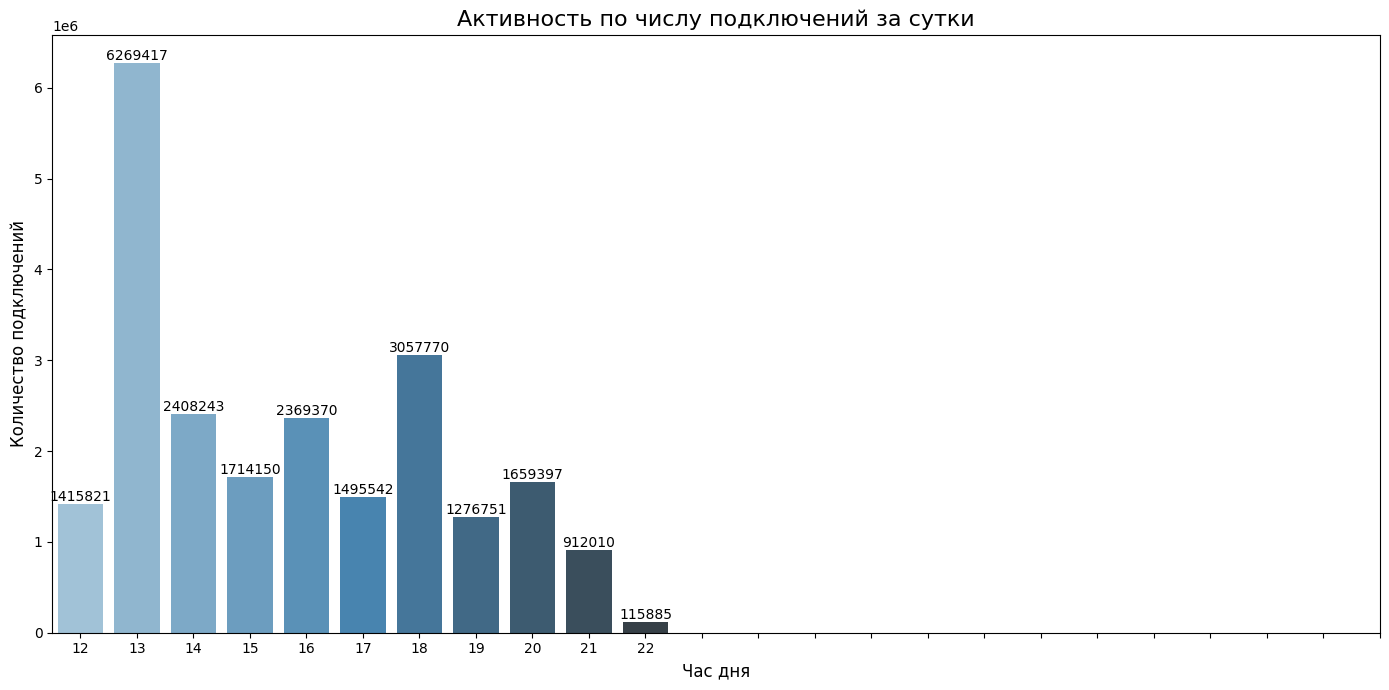

In [14]:
# Временной график активности по числу подключений за сутки (по часам)
df['hour'] = df['timestamp'].dt.hour
hourly_activity = df.groupby('hour').size()

plt.figure(figsize=(14,7))
sns.barplot(x=hourly_activity.index, y=hourly_activity.values, palette='Blues_d')
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество подключений', fontsize=12)
plt.title('Активность по числу подключений за сутки', fontsize=16)
plt.xticks(range(0,24))
for index, value in enumerate(hourly_activity.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()



### Топ-15 IP по объему трафика



<ipython-input-15-f73b68bc3217>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_traffic_ips.values, y=top_traffic_ips.index, palette='coolwarm')


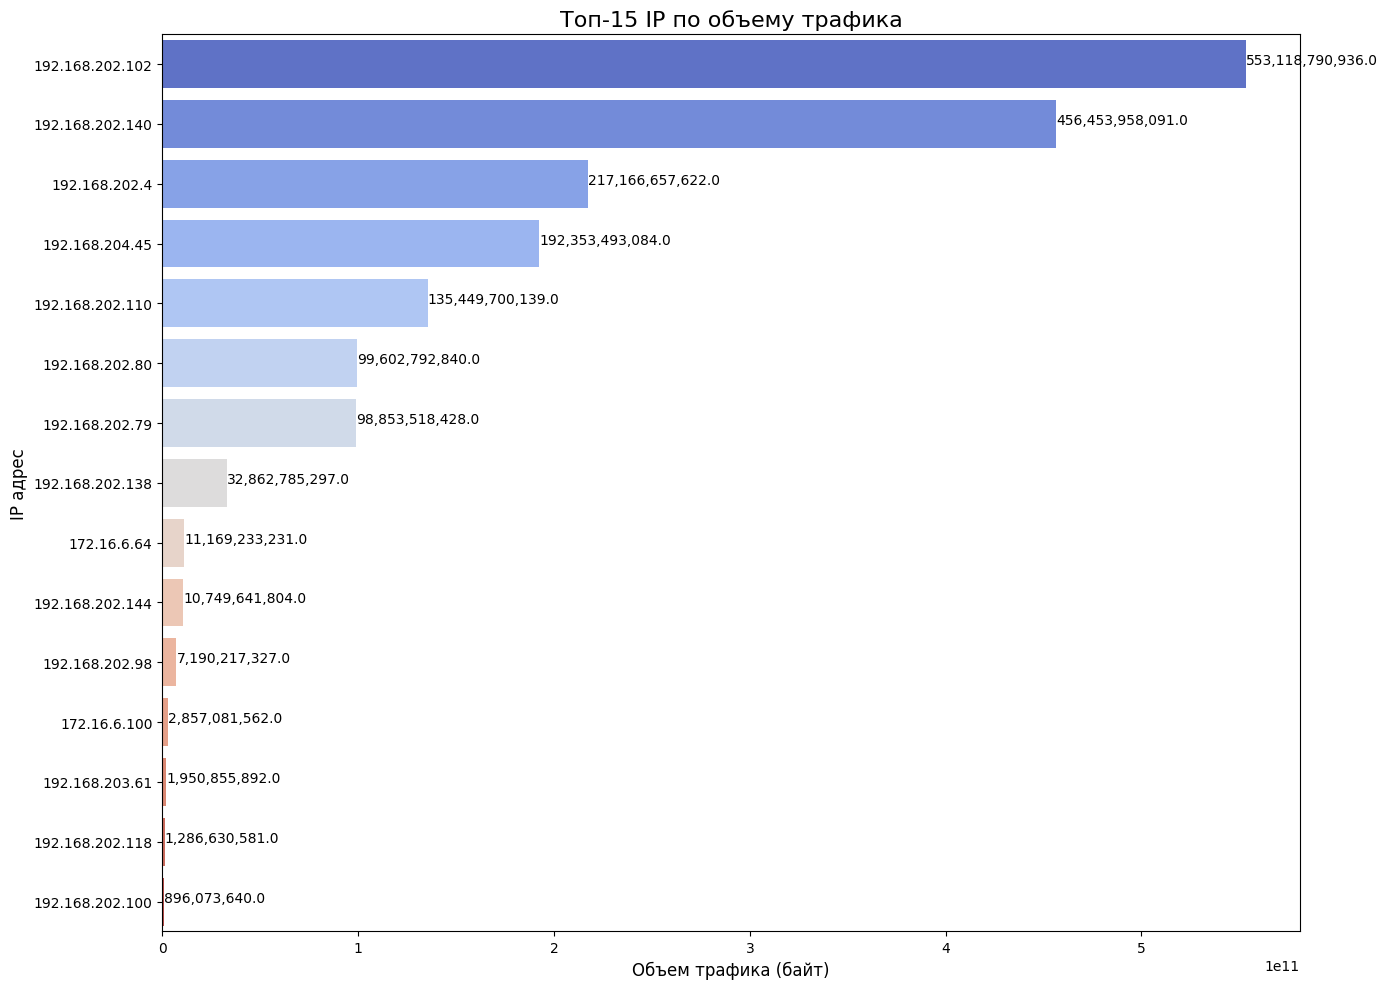

In [15]:
# Топ-15 IP по объему трафика
df['total_bytes'] = df['bytes_sent'] + df['bytes_received']
top_traffic_ips = df.groupby('src_ip')['total_bytes'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,10))
sns.barplot(x=top_traffic_ips.values, y=top_traffic_ips.index, palette='coolwarm')
plt.xlabel('Объем трафика (байт)', fontsize=12)
plt.ylabel('IP адрес', fontsize=12)
plt.title('Топ-15 IP по объему трафика', fontsize=16)
for index, value in enumerate(top_traffic_ips.values):
    plt.text(value, index, f'{value:,}', fontsize=10)
plt.tight_layout()
plt.show()



### Ранжирование по длительности сессий (топ-15)



<ipython-input-16-0ac331f1bdb3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_duration.values, y=top_duration.index, palette='inferno')


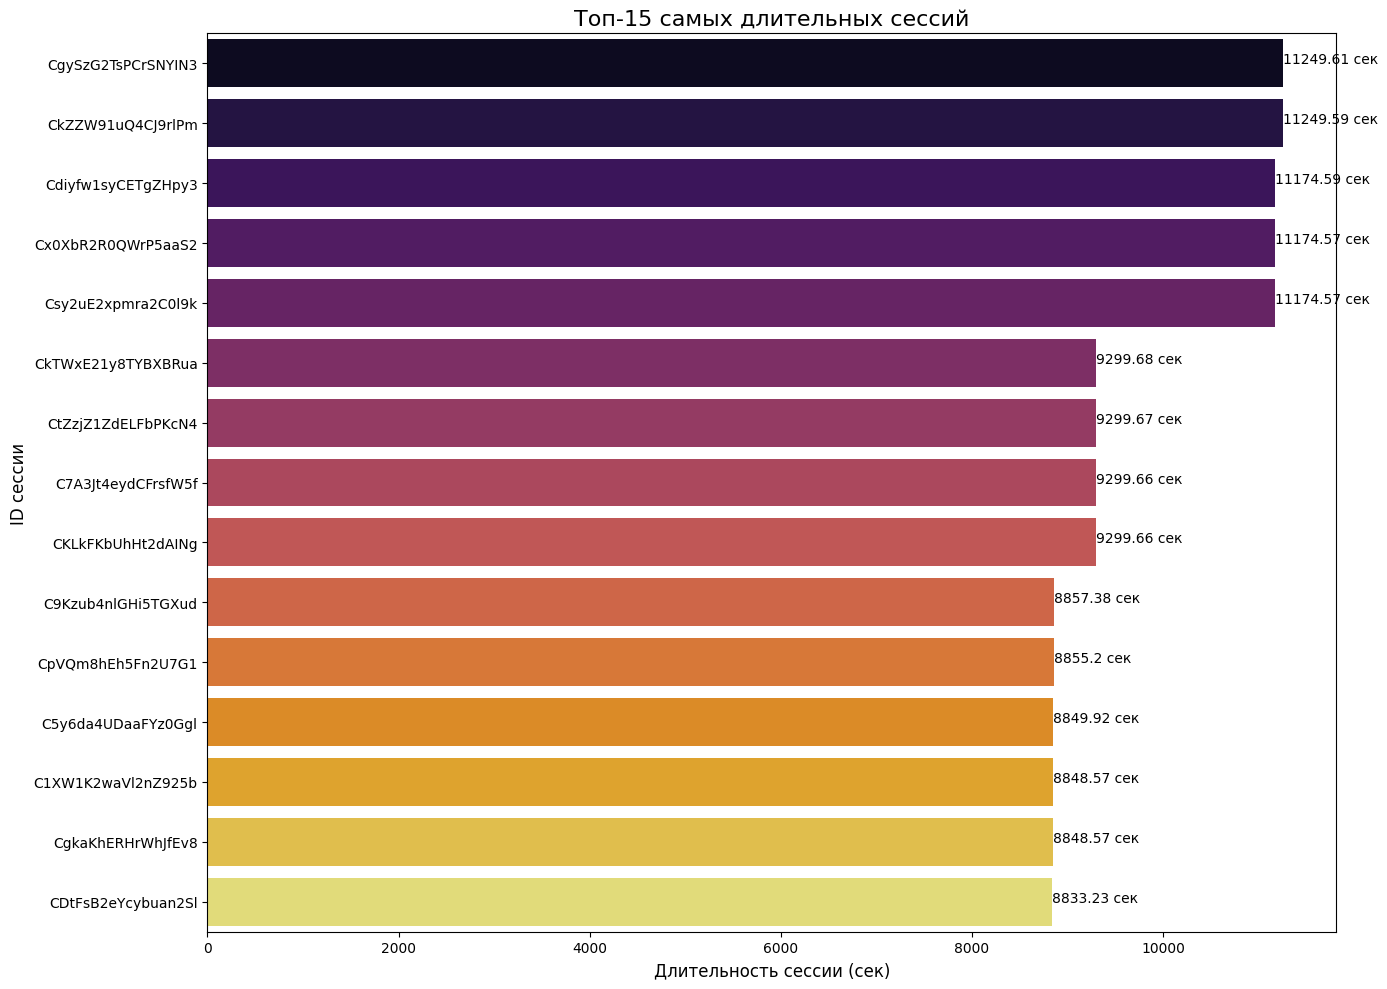

In [16]:
# Ранжирование по длительности сессий (топ-15)
top_duration = df.groupby('session_id')['duration'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14,10))
sns.barplot(x=top_duration.values, y=top_duration.index, palette='inferno')
plt.xlabel('Длительность сессии (сек)', fontsize=12)
plt.ylabel('ID сессии', fontsize=12)
plt.title('Топ-15 самых длительных сессий', fontsize=16)
for index, value in enumerate(top_duration.values):
    plt.text(value, index, f'{value} сек', fontsize=10)
plt.tight_layout()
plt.show()



### Топ-10 IP по объему переданных данных



<ipython-input-17-02b73c2413f1>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bytes_sent.values, y=top_bytes_sent.index, palette='Oranges')


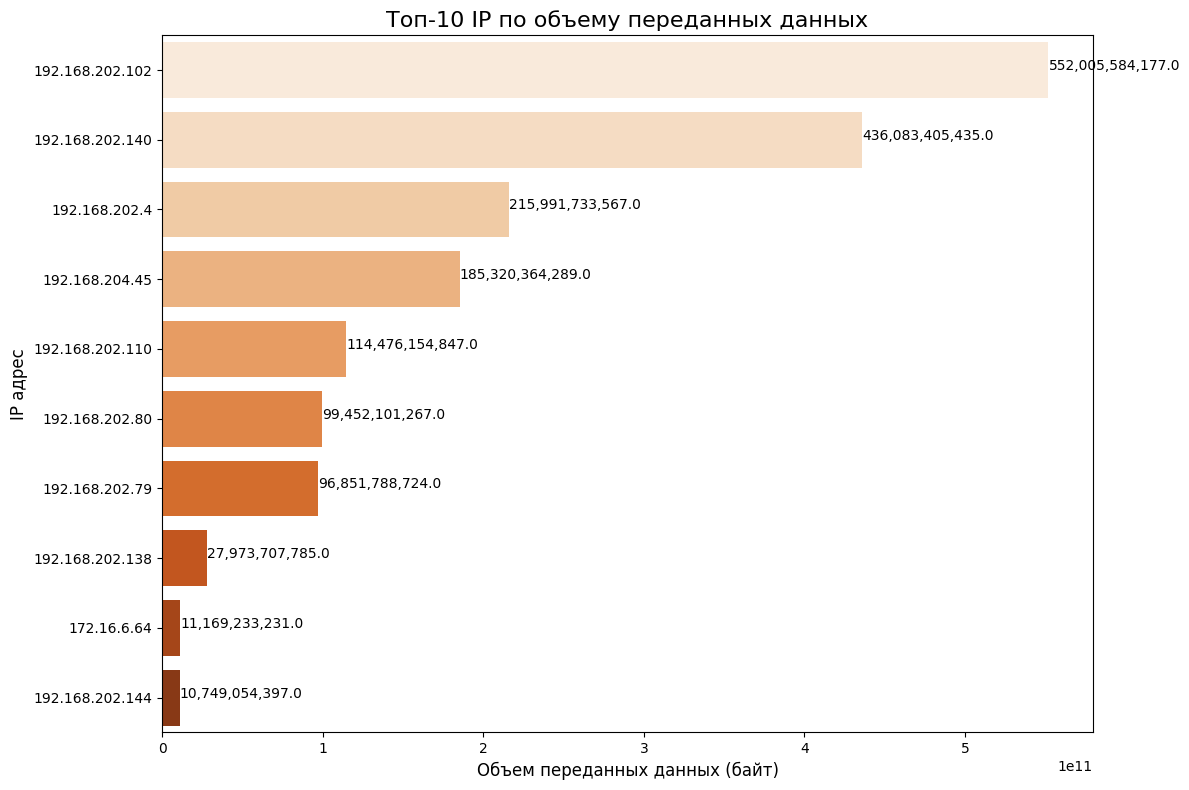

In [17]:
# Дополнительный график: Топ-10 IP по объему переданных данных
top_bytes_sent = df.groupby('src_ip')['bytes_sent'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,8))
sns.barplot(x=top_bytes_sent.values, y=top_bytes_sent.index, palette='Oranges')
plt.xlabel('Объем переданных данных (байт)', fontsize=12)
plt.ylabel('IP адрес', fontsize=12)
plt.title('Топ-10 IP по объему переданных данных', fontsize=16)
for index, value in enumerate(top_bytes_sent.values):
    plt.text(value, index, f'{value:,}', fontsize=10)
plt.tight_layout()
plt.show()



---
## Подготовка данных для модели



In [18]:
# Выбор признаков и целевой переменной
features = [
    'src_port', 'dst_port', 'protocol', 'app_protocol',
    'duration', 'bytes_sent', 'bytes_received',
    'packets_sent', 'packets_received'
]

X = balanced_df[features]
y = balanced_df['label']



### Преобразование категориальных признаков в числовые (one-hot encoding)



In [19]:
# Преобразование категориальных признаков в числовые (one-hot encoding)
categorical_features = ['protocol', 'app_protocol']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)



### Кодирование меток



In [20]:
# Кодирование меток
le = LabelEncoder()
y_encoded = le.fit_transform(y)



### Масштабирование данных



In [21]:
# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



### Разделение на обучающую и тестовую выборки



In [22]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)



---
## Построение и обучение модели

### Определение архитектуры модели



In [23]:
# Определение архитектуры модели
num_classes = len(le.classes_)
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               4608      
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 32)                2080      
                                                                 
 dense_4 (Dense)             (None, 5)                 165       
                                                                 
Total params: 48005 (187.52 KB)
Trainable params: 48005 (187.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________



### Вычисление весов классов



In [24]:
# Вычисление весов классов для учета дисбаланса
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))
print("Веса классов:", class_weights_dict)


Веса классов: {0: 2.6276319278705915, 1: 0.6061540343793969, 2: 28.97309941520468, 3: 0.7079737067733638, 4: 0.6567338282078473}



### Обучение модели с использованием весов классов



In [25]:
# Обучение модели с учетом весов классов
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)


Epoch 1/20
7432/7432 [==============================] - 19s 2ms/step - loss: 0.5284 - accuracy: 0.7781 - val_loss: 0.5602 - val_accuracy: 0.8058
Epoch 2/20
7432/7432 [==============================] - 17s 2ms/step - loss: 0.4144 - accuracy: 0.8240 - val_loss: 0.5514 - val_accuracy: 0.8062
Epoch 3/20
7432/7432 [==============================] - 18s 2ms/step - loss: 0.3721 - accuracy: 0.8451 - val_loss: 0.6860 - val_accuracy: 0.7484
Epoch 4/20
7432/7432 [==============================] - 17s 2ms/step - loss: 0.3343 - accuracy: 0.8668 - val_loss: 0.3336 - val_accuracy: 0.8873
Epoch 5/20
7432/7432 [==============================] - 17s 2ms/step - loss: 0.3263 - accuracy: 0.8723 - val_loss: 0.3914 - val_accuracy: 0.8759
Epoch 6/20
7432/7432 [==============================] - 18s 2ms/step - loss: 0.3202 - accuracy: 0.8707 - val_loss: 0.4627 - val_accuracy: 0.8643
Epoch 7/20
7432/7432 [==============================] - 17s 2ms/step - loss: 0.3198 - accuracy: 0.8778 - val_loss: 0.3732 - val_ac


---
## Оценка модели



In [26]:
# Оценка на тестовой выборке
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nТочность на тестовых данных: {test_acc:.4f}')

# Сохранение модели
model.save('balanced_network_attack_model.h5')


1162/1162 - 1s - loss: 0.3439 - accuracy: 0.8857 - 1s/epoch - 1ms/step

Точность на тестовых данных: 0.8857


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



### Предсказания и отчет классификации



In [27]:
# Предсказания
y_pred = np.argmax(model.predict(X_test), axis=1)

# Отчет классификации
print(classification_report(y_test, y_pred, target_names=le.classes_))


1162/1162 [==============================] - 1s 1ms/step
              precision    recall  f1-score   support

        DDoS       0.95      1.00      0.98      2829
    Flooding       0.89      0.87      0.88     12261
      Normal       0.43      0.90      0.59       256
    Spoofing       0.88      0.80      0.84     10497
  Suspicious       0.89      0.96      0.92     11316

    accuracy                           0.89     37159
   macro avg       0.81      0.90      0.84     37159
weighted avg       0.89      0.89      0.89     37159




### Матрица путаницы



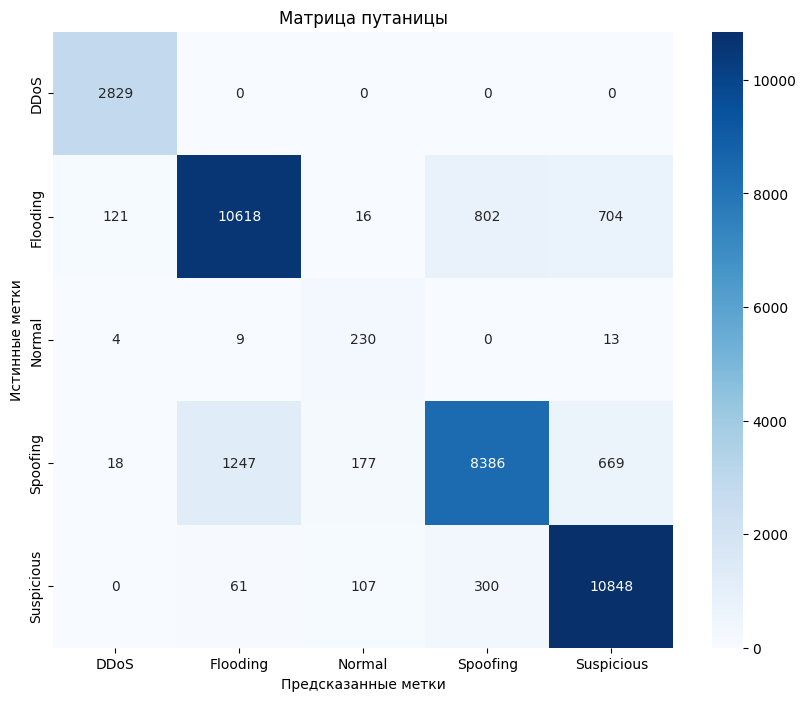

In [28]:
# Матрица путаницы
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица путаницы')
plt.show()


### Распределение предсказанных меток на тестовой выборке


<ipython-input-29-1835926f1ca5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y_pred_labels, order=le.classes_, palette='Set3')


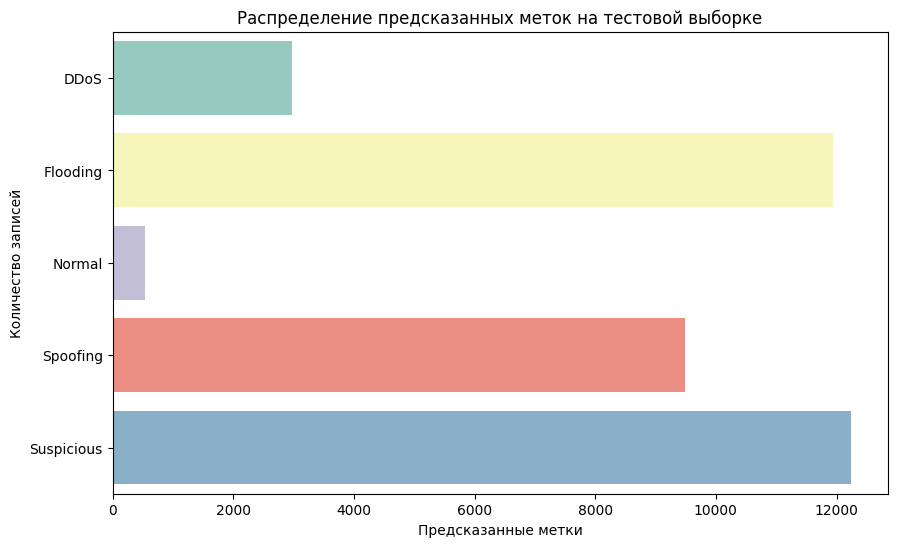

In [29]:
# Распределение предсказанных меток на тестовой выборке
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

plt.figure(figsize=(10,6))
sns.countplot(y_pred_labels, order=le.classes_, palette='Set3')
plt.xlabel('Предсказанные метки')
plt.ylabel('Количество записей')
plt.title('Распределение предсказанных меток на тестовой выборке')
plt.show()



### Нормализованная матрица путаницы



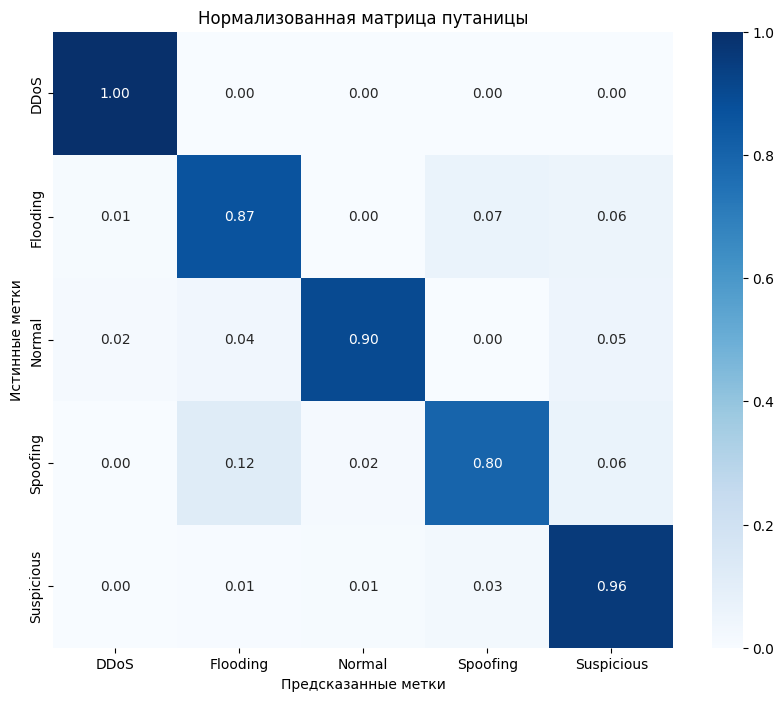

In [30]:
# Нормализованная матрица путаницы
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Нормализованная матрица путаницы')
plt.show()



### Визуализация распределения тестовых данных после обучения модели



<ipython-input-31-5112d006d940>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test_labels, palette='Set2', label='Истинные метки')
<ipython-input-31-5112d006d940>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred_labels, palette='coolwarm', alpha=0.5, label='Предсказанные метки')


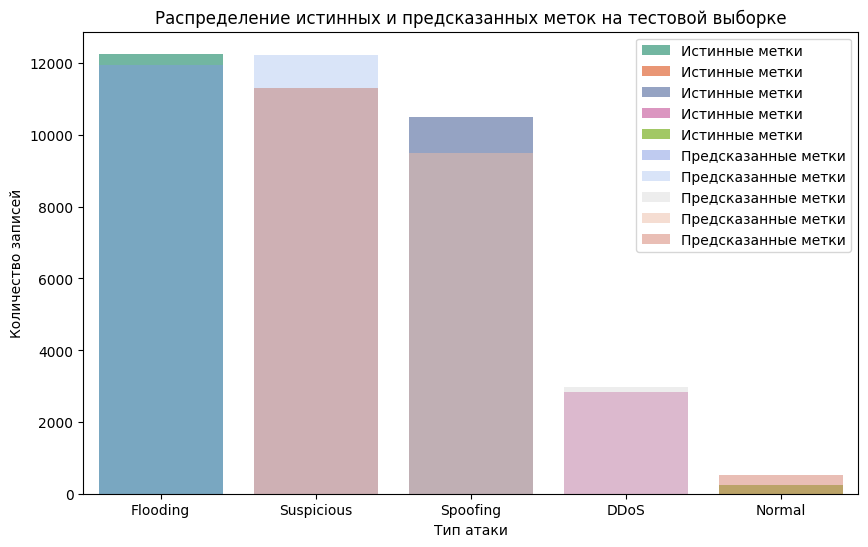

In [31]:
# Визуализация распределения тестовых данных после обучения модели
plt.figure(figsize=(10,6))
sns.countplot(x=y_test_labels, palette='Set2', label='Истинные метки')
sns.countplot(x=y_pred_labels, palette='coolwarm', alpha=0.5, label='Предсказанные метки')
plt.xlabel('Тип атаки')
plt.ylabel('Количество записей')
plt.title('Распределение истинных и предсказанных меток на тестовой выборке')
plt.legend()
plt.show()


### Визуализация точности

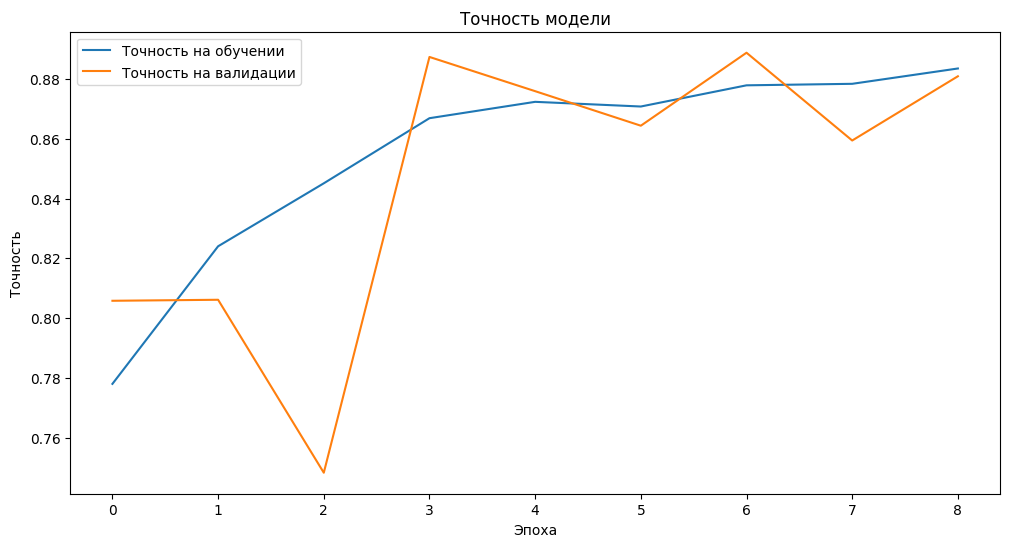

In [32]:
# Визуализация точности
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Точность модели')
plt.legend()
plt.show()



### Визуализация потерь



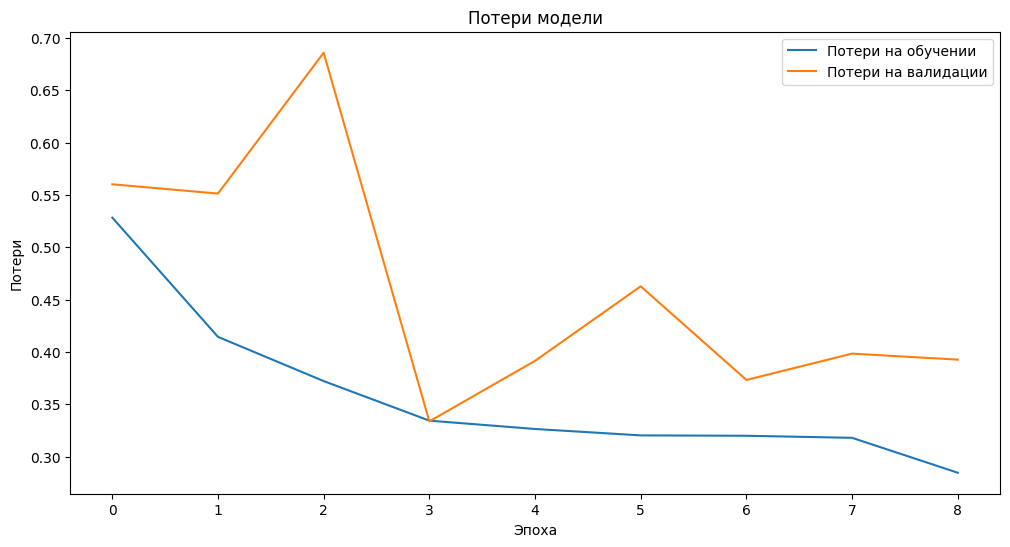

In [33]:
# Визуализация потерь
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.title('Потери модели')
plt.legend()
plt.show()
